# Seasonality — Fourier Components, SARMA, and SARIMA

BeTiSe supports several ways to generate seasonal time series. The current implementation uses
**calendar-aware seasonal periods** and stores their possible interpretations in the metadata.

**Seasonal generators:**
- **Single seasonality:** one deterministic Fourier seasonal component
- **Multiple seasonality:** two or more Fourier seasonal components with different periods
- **SARMA:** deterministic Fourier seasonality + stationary SARMA error process + observation noise
- **SARIMA:** seasonal unit-root process where  
  \[
  Y_t - Y_{t-s} = \text{Fourier}(t) + \varepsilon_t
  \]

**Key Features:**
- Calendar-meaningful periods are selected according to series length
- The selected period(s) and their meanings are stored in `info["period_meanings"]`
- Fourier harmonics control the shape of deterministic seasonal patterns
- SARMA preserves stationary seasonal dependence in the error process
- SARIMA explicitly introduces a seasonal unit root through seasonal integration

This notebook demonstrates:
1. Inspecting valid calendar-aware seasonal periods
2. Generating single and multiple Fourier seasonalities
3. Generating SARMA and SARIMA seasonal series
4. Comparing the four seasonal structures
5. Inspecting dominant frequencies with the periodogram
6. Visualizing the effect of seasonal differencing in SARIMA
7. Applying contextual anomalies to all four seasonal structures
8. Using the unified seasonal generation API


## 1 · Setup and Imports


In [3]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import periodogram
from statsmodels.graphics.tsaplots import plot_acf

from betise.core.generator import TimeSeriesGenerator

np.random.seed(42)
random.seed(42)

print("✓ BeTiSe imported successfully")


✓ BeTiSe imported successfully


## 2 · Calendar-Aware Seasonal Periods

Seasonal periods are interpreted as **number of observations per cycle**.

BeTiSe keeps a set of calendar-meaningful periods for common sampling frequencies
(monthly, quarterly, daily, weekly, business-daily, and hourly data). A period is only
considered valid if enough complete cycles fit inside the generated series.

By default, `min_cycles=6`.


In [4]:
length = np.random.randint(100, 1000)
ts_gen = TimeSeriesGenerator(length=length)

valid_periods = ts_gen.get_valid_calendar_periods(min_cycles=6)

print(f"Valid seasonal periods for length={length}:")
print(valid_periods)

print("\nPossible calendar meanings:")
for period in valid_periods:
    meanings = ts_gen.get_period_meanings(period)
    if meanings:
        print(f"  Period {period}:")
        for item in meanings:
            print(
                f"    - {item['sampling_frequency']}: "
                f"{item['meaning']}"
            )


Valid seasonal periods for length=202:
[3, 4, 5, 6, 7, 12, 13, 21, 24, 26, 30]

Possible calendar meanings:
  Period 3:
    - monthly: quarterly cycle
  Period 4:
    - quarterly: annual cycle
    - weekly: monthly-ish cycle
  Period 5:
    - business_daily: weekly cycle
  Period 6:
    - monthly: semiannual cycle
  Period 7:
    - daily: weekly cycle
  Period 12:
    - monthly: annual cycle
  Period 13:
    - weekly: quarterly cycle
  Period 21:
    - business_daily: monthly-ish cycle
  Period 24:
    - hourly: daily cycle
  Period 26:
    - weekly: semiannual cycle
  Period 30:
    - daily: monthly-ish cycle


## 3 · Generate a Single Fourier Seasonality

A single seasonal pattern is generated from a Fourier component

\[
f_t = \sum_{k=1}^{K}
\left[
A_k \sin\left(\frac{2\pi kt}{s}\right)
+
B_k \cos\left(\frac{2\pi kt}{s}\right)
\right]
\]

where `s` is the seasonal period and `K = num_harmonics`.

Here, `period=24` can represent a **daily cycle for hourly data**.


In [5]:
ts_gen = TimeSeriesGenerator(length=length)
period = random.choice(valid_periods)

df_single, info_single = ts_gen.generate_single_seasonality(
    period=period,
    scale_factor=2,
    num_harmonics=1
)

print("Generated single-seasonality series:")
print(f"  Length: {len(df_single)}")
print(f"  Period: {info_single['periods'][0]}")
print(f"  Period meanings: {info_single['period_meanings']}")
print(f"  Amplitude: {info_single['amplitude']:.4f}")
print(f"  Noise std: {info_single['noise_std']:.4f}")
print(f"  Harmonics: {info_single['num_harmonics']}")
print(f"  Fourier coefficients: {info_single['coefficients']}")


Generated single-seasonality series:
  Length: 202
  Period: 30
  Period meanings: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Amplitude: 0.3957
  Noise std: 0.0329
  Harmonics: 1
  Fourier coefficients: [{'harmonic': 1, 'sin_coef': np.float64(0.20645639944645514), 'cos_coef': np.float64(0.394582434558509)}]


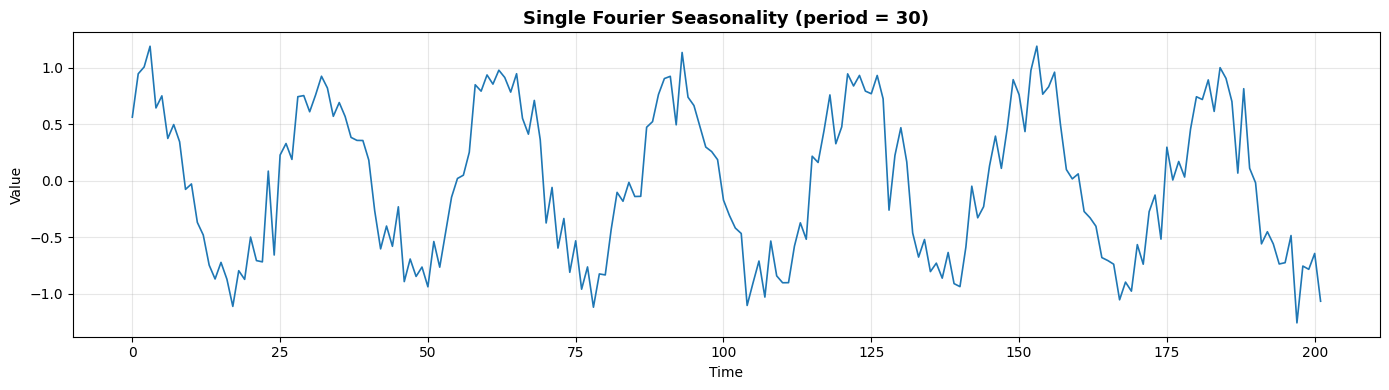

In [6]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_single["time"], df_single["data"], linewidth=1.2)
ax.set_title(
    f"Single Fourier Seasonality (period = {info_single['periods'][0]})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4 · Generate Multiple Seasonalities

Multiple seasonality is created by summing independent Fourier seasonal components
with different periods.

In this example:
- `period=7` → weekly cycle for daily observations
- `period=30` → monthly-ish cycle for daily observations

The metadata stores the periods, amplitudes, calendar meanings, and Fourier
coefficients separately for each component.


In [10]:
periods = random.sample(valid_periods, k=min(2, len(valid_periods)))
ts_gen = TimeSeriesGenerator(length=length)

df_multiple, info_multiple = ts_gen.generate_multiple_seasonality(
    periods=periods,
    scale_factor=3,
    num_harmonics=1
)

print("Generated multiple-seasonality series:")
print(f"  Length: {len(df_multiple)}")
print(f"  Periods: {info_multiple['periods']}")
print(f"  Period meanings: {info_multiple['period_meanings']}")
print(f"  Amplitudes: {[round(x, 4) for x in info_multiple['amplitudes']]}")
print(f"  Noise std: {info_multiple['noise_std']:.4f}")
print(f"  Harmonics per period: {info_multiple['num_harmonics']}")


Generated multiple-seasonality series:
  Length: 202
  Periods: [6, 5]
  Period meanings: {6: [{'sampling_frequency': 'monthly', 'meaning': 'semiannual cycle'}], 5: [{'sampling_frequency': 'business_daily', 'meaning': 'weekly cycle'}]}
  Amplitudes: [np.float64(0.2691), np.float64(0.1798)]
  Noise std: 0.0347
  Harmonics per period: 1


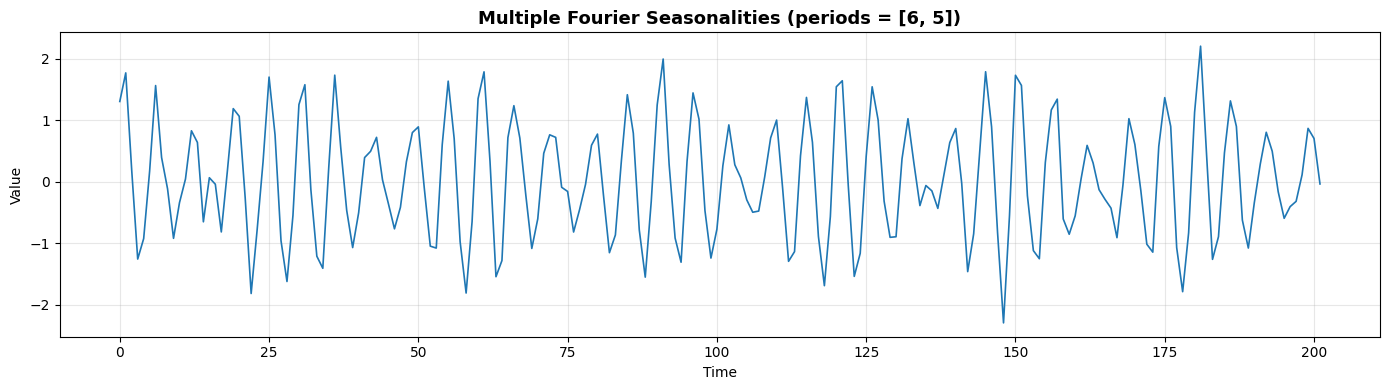

In [11]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_multiple["time"], df_multiple["data"], linewidth=1.2)
ax.set_title(
    f"Multiple Fourier Seasonalities (periods = {info_multiple['periods']})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 5 · Generate a SARMA Seasonal Series

BeTiSe represents SARMA-style seasonality as

\[
Y_t = f_t + u_t + e_t
\]

where:
- \(f_t\) is deterministic Fourier seasonality,
- \(u_t\) is a stationary and invertible SARMA error process,
- \(e_t\) is small observation noise.

There is **no differencing and no seasonal unit root** in this case.


In [13]:
ts_gen = TimeSeriesGenerator(length=length)

df_sarma, info_sarma = ts_gen.generate_sarma_series(
    period=period,
    scale_factor=1,
    num_harmonics=1
)

print("Generated SARMA seasonal series:")
print(f"  Period: {info_sarma['periods'][0]}")
print(f"  Period meanings: {info_sarma['period_meanings']}")
print(f"  Unit root: {info_sarma['unit_root']}")
print(f"  AR order: {info_sarma['ar_order']}")
print(f"  MA order: {info_sarma['ma_order']}")
print(f"  Seasonal AR order: {info_sarma['seasonal_ar_order']}")
print(f"  Seasonal MA order: {info_sarma['seasonal_ma_order']}")
print(f"  Fourier coefficients: {info_sarma['fourier_coefficients']}")


Generated SARMA seasonal series:
  Period: 30
  Period meanings: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Unit root: none
  AR order: 1
  MA order: 2
  Seasonal AR order: 1
  Seasonal MA order: 1
  Fourier coefficients: [{'harmonic': 1, 'sin_coef': np.float64(0.15257219395231963), 'cos_coef': np.float64(0.144955697677798)}]


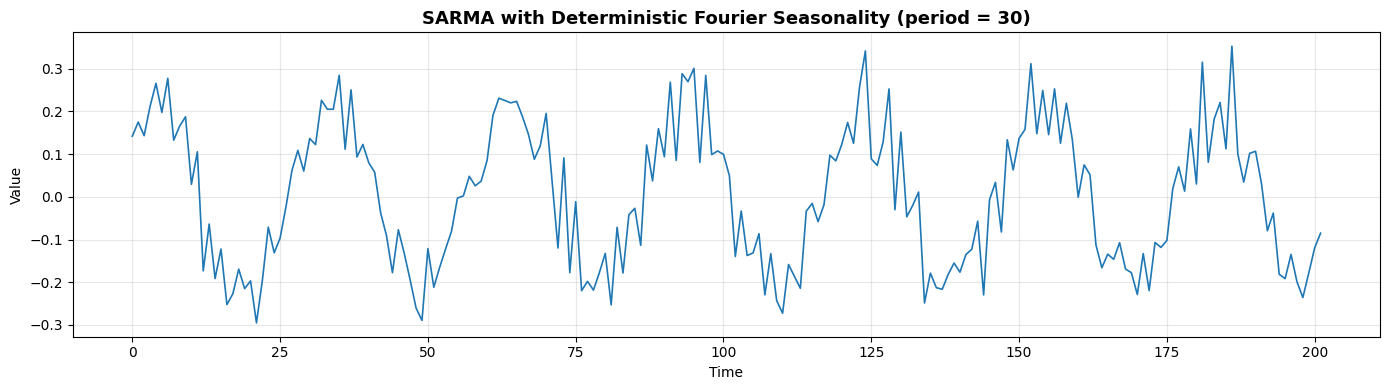

In [14]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_sarma["time"], df_sarma["data"], linewidth=1.2)
ax.set_title(
    f"SARMA with Deterministic Fourier Seasonality "
    f"(period = {info_sarma['periods'][0]})",
    fontsize=13,
    fontweight="bold"
)
ax.set_xlabel("Time")
ax.set_ylabel("Value")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 6 · Generate a SARIMA Seasonal Unit-Root Series

The SARIMA generator explicitly creates a seasonal unit root:

\[
Y_t - Y_{t-s}
=
\text{Fourier}(t) + \varepsilon_t
\]

Therefore, the raw series is seasonally integrated, while the seasonal difference
\(Y_t - Y_{t-s}\) reveals the underlying deterministic seasonal structure plus noise.

The generated dataframe includes a `seasonal_diff` column for this quantity.


In [15]:
ts_gen = TimeSeriesGenerator(length=length)

df_sarima, info_sarima = ts_gen.generate_sarima_series(
    period=period,
    scale_factor=1,
    num_harmonics=1
)

print("Generated SARIMA seasonal unit-root series:")
print(f"  Period: {info_sarima['periods'][0]}")
print(f"  Period meanings: {info_sarima['period_meanings']}")
print(f"  Non-seasonal differencing order: {info_sarima['diff']}")
print(f"  Seasonal differencing order: {info_sarima['seasonal_diff']}")
print(f"  Unit root: {info_sarima['unit_root']}")
print(f"  Harmonics: {info_sarima['num_harmonics']}")
print(f"  Fourier coefficients: {info_sarima['coefficients']}")


Generated SARIMA seasonal unit-root series:
  Period: 30
  Period meanings: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Non-seasonal differencing order: 0
  Seasonal differencing order: 1
  Unit root: seasonal_unit_root
  Harmonics: 1
  Fourier coefficients: [{'harmonic': 1, 'sin_coef': np.float64(0.23907410797334624), 'cos_coef': np.float64(0.1680776818767884)}]


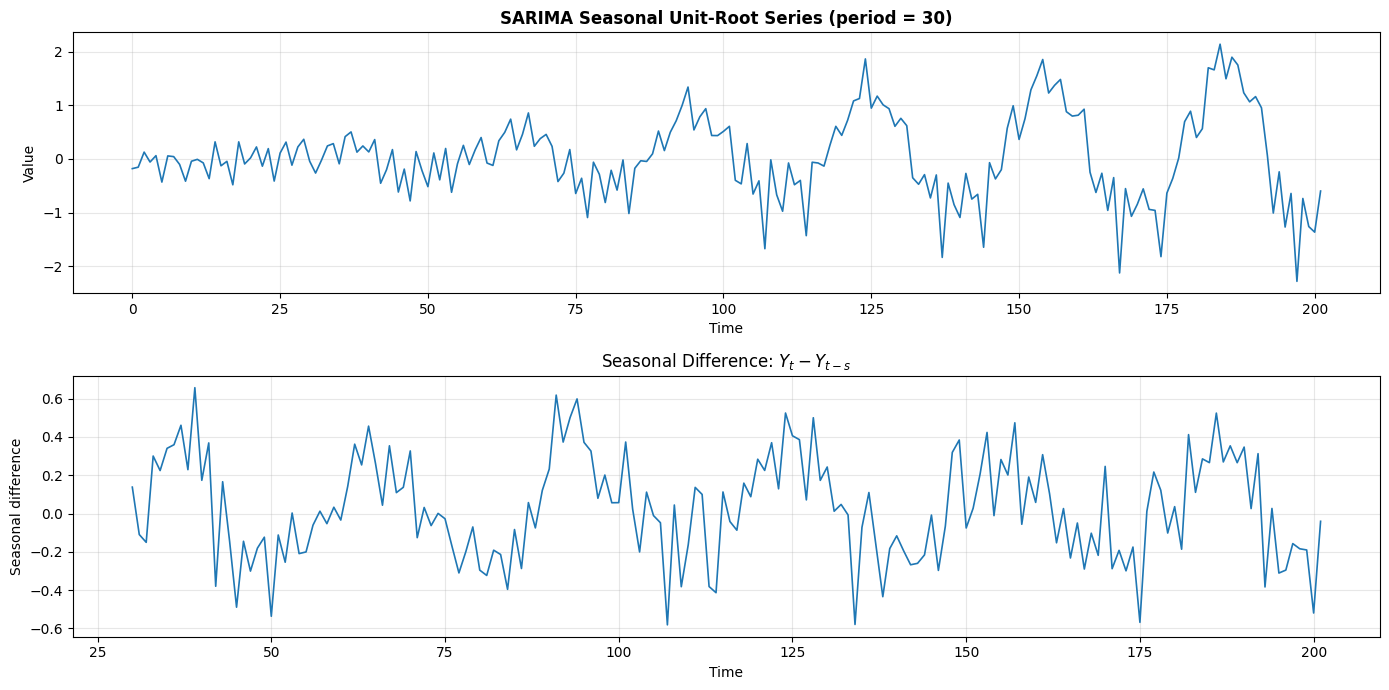

In [16]:
fig, axes = plt.subplots(2, 1, figsize=(14, 7))

axes[0].plot(df_sarima["time"], df_sarima["data"], linewidth=1.2)
axes[0].set_title(
    f"SARIMA Seasonal Unit-Root Series "
    f"(period = {info_sarima['periods'][0]})",
    fontsize=12,
    fontweight="bold"
)
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Value")
axes[0].grid(alpha=0.3)

axes[1].plot(
    df_sarima["time"],
    df_sarima["seasonal_diff"],
    linewidth=1.2
)
axes[1].set_title(r"Seasonal Difference: $Y_t - Y_{t-s}$", fontsize=12)
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Seasonal difference")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 7 · Compare the Four Seasonal Structures

The four generators represent different seasonal mechanisms:

- **Single:** one deterministic Fourier cycle
- **Multiple:** several deterministic Fourier cycles
- **SARMA:** Fourier seasonality with stationary seasonal dependence in the errors
- **SARIMA:** seasonal integration with an explicit seasonal unit root


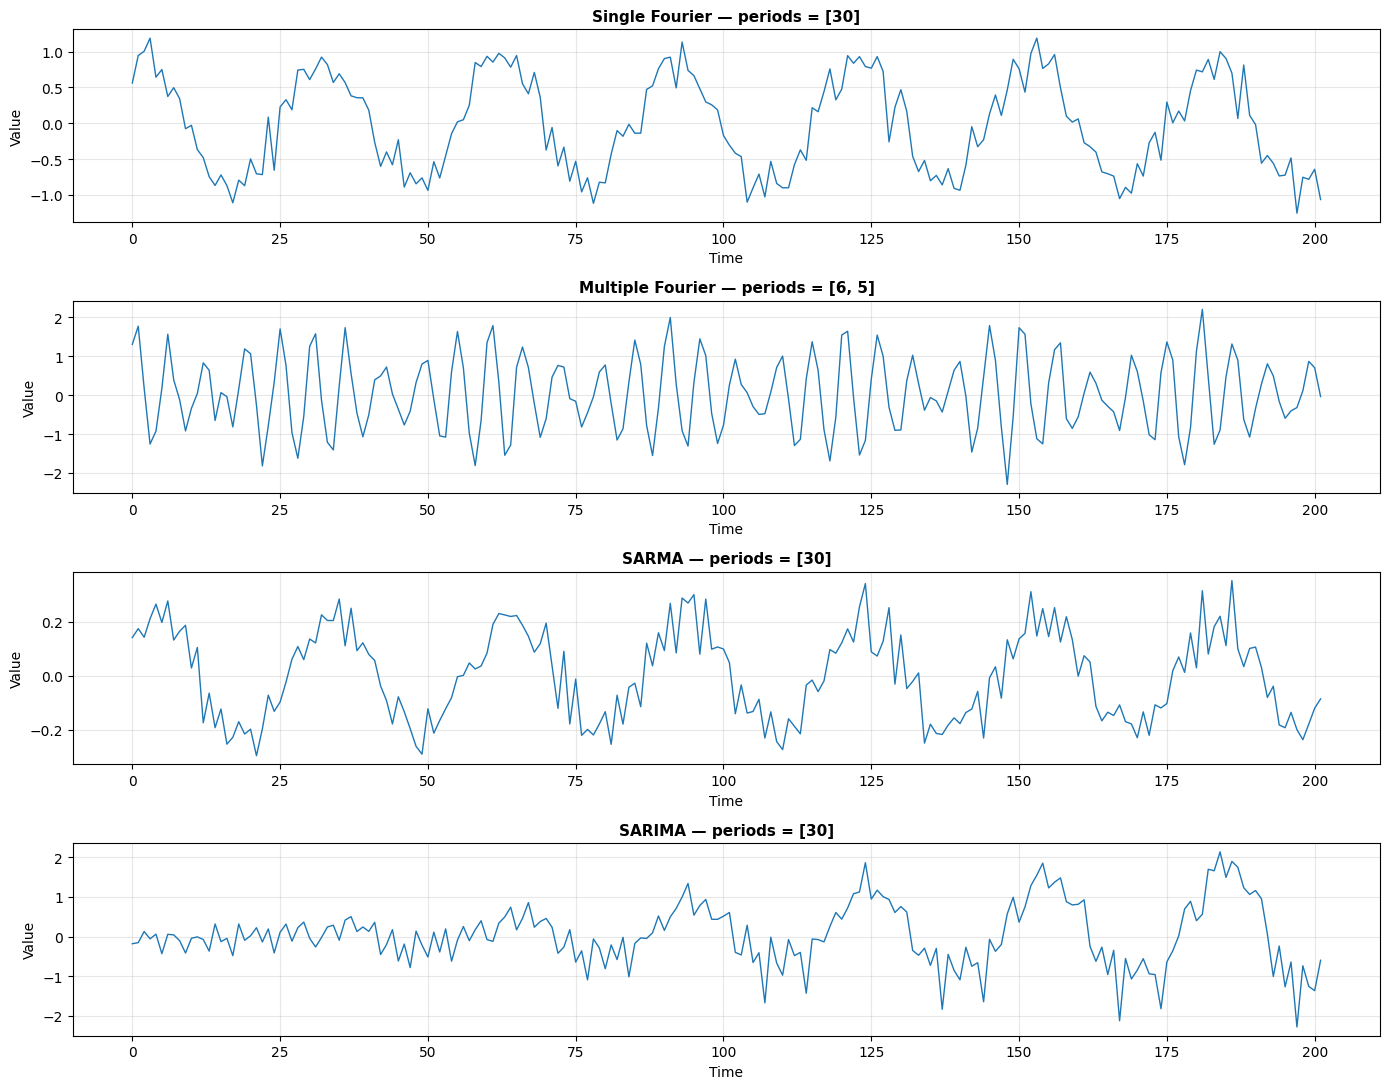

In [17]:
seasonal_examples = {
    "Single Fourier": (df_single, info_single),
    "Multiple Fourier": (df_multiple, info_multiple),
    "SARMA": (df_sarma, info_sarma),
    "SARIMA": (df_sarima, info_sarima),
}

fig, axes = plt.subplots(4, 1, figsize=(14, 11))

for ax, (label, (df_example, info_example)) in zip(
    axes,
    seasonal_examples.items()
):
    ax.plot(df_example["time"], df_example["data"], linewidth=1.0)
    ax.set_title(
        f"{label} — periods = {info_example['periods']}",
        fontsize=11,
        fontweight="bold"
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## 8 · Contextual Anomalies on Seasonal Series

A contextual anomaly is generated **only after seasonality already exists**.

The contextual-anomaly generator does not create a new seasonal pattern. Instead, it:

1. reads the existing seasonal metadata from the corresponding `info` dictionary,
2. selects one existing seasonal period,
3. reconstructs the Fourier seasonal context associated with that period,
4. finds contextually meaningful peak/valley regions,
5. locally violates that expected seasonal behavior.

For a series with multiple seasonal periods, one of the existing periods is selected randomly.

For SARIMA, the stored Fourier term belongs to the seasonally differenced domain,

\[
Y_t - Y_{t-s} = F_t + \varepsilon_t.
\]

Therefore, the Fourier term is seasonally integrated before it is used as the contextual
reference in the observed-series domain.

The examples below apply the same contextual-anomaly interface to:

- single Fourier seasonality,
- multiple Fourier seasonality,
- SARMA,
- SARIMA.


In [18]:
def plot_contextual_case(
    clean_df,
    anomaly_df,
    seasonal_info,
    anomaly_info,
    title
):
    x = clean_df["time"].to_numpy()

    fig, axes = plt.subplots(
        2,
        1,
        figsize=(14, 7),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1]}
    )

    # --------------------------------------------------
    # Clean series vs contextual-anomaly series
    # --------------------------------------------------
    axes[0].plot(
        x,
        clean_df["data"],
        label="Clean seasonal series",
        linewidth=1.2
    )

    axes[0].plot(
        x,
        anomaly_df["data"],
        label="With contextual anomaly",
        linewidth=1.0,
        alpha=0.85
    )

    for start, end in zip(
        anomaly_info["starts"],
        anomaly_info["ends"]
    ):
        axes[0].axvspan(
            start,
            end,
            alpha=0.20
        )

    chosen_period = anomaly_info["periods"][0]

    axes[0].set_title(
        f"{title}\n"
        f"source periods = {seasonal_info['periods']} | "
        f"context period = {chosen_period}",
        fontsize=12,
        fontweight="bold"
    )
    axes[0].set_ylabel("Value")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # --------------------------------------------------
    # Actual perturbation introduced by the anomaly
    # --------------------------------------------------
    difference = (
        anomaly_df["data"].to_numpy()
        - clean_df["data"].to_numpy()
    )

    axes[1].plot(
        x,
        difference,
        linewidth=1.1
    )
    axes[1].axhline(0, linewidth=0.8)

    for start, end in zip(
        anomaly_info["starts"],
        anomaly_info["ends"]
    ):
        axes[1].axvspan(
            start,
            end,
            alpha=0.20
        )

    axes[1].set_xlabel("Time")
    axes[1].set_ylabel("Anomaly effect")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


def check_contextual_case(
    clean_df,
    anomaly_df,
    seasonal_info,
    anomaly_info
):
    chosen_period = anomaly_info["periods"][0]

    assert chosen_period in seasonal_info["periods"], (
        "The contextual period must come from the "
        "original seasonal periods."
    )

    assert anomaly_info["num_anomalies"] > 0

    assert "context_anom_label" in anomaly_df.columns

    expected_mask = np.zeros(
        len(anomaly_df),
        dtype=bool
    )

    for start, end in zip(
        anomaly_info["starts"],
        anomaly_info["ends"]
    ):
        expected_mask[start:end] = True

    label_mask = (
        anomaly_df["context_anom_label"]
        .to_numpy()
        .astype(bool)
    )

    assert np.array_equal(
        expected_mask,
        label_mask
    )

    changed = ~np.isclose(
        clean_df["data"].to_numpy(),
        anomaly_df["data"].to_numpy()
    )

    assert not changed[~expected_mask].any(), (
        "Values outside the contextual anomaly "
        "intervals were modified."
    )

    print("PASS")
    print(f"  Source periods: {seasonal_info['periods']}")
    print(f"  Chosen context period: {chosen_period}")
    print(f"  Period meaning: {anomaly_info['period_meanings']}")
    print(
        "  Intervals:",
        list(
            zip(
                anomaly_info["starts"],
                anomaly_info["ends"]
            )
        )
    )


### 8.1 · Single Fourier Seasonality + Contextual Anomaly

The single-seasonality case has only one possible seasonal context, so the contextual
anomaly must use that existing period.


PASS
  Source periods: [30]
  Chosen context period: 30
  Period meaning: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Intervals: [(np.int64(25), np.int64(40)), (np.int64(70), np.int64(85))]


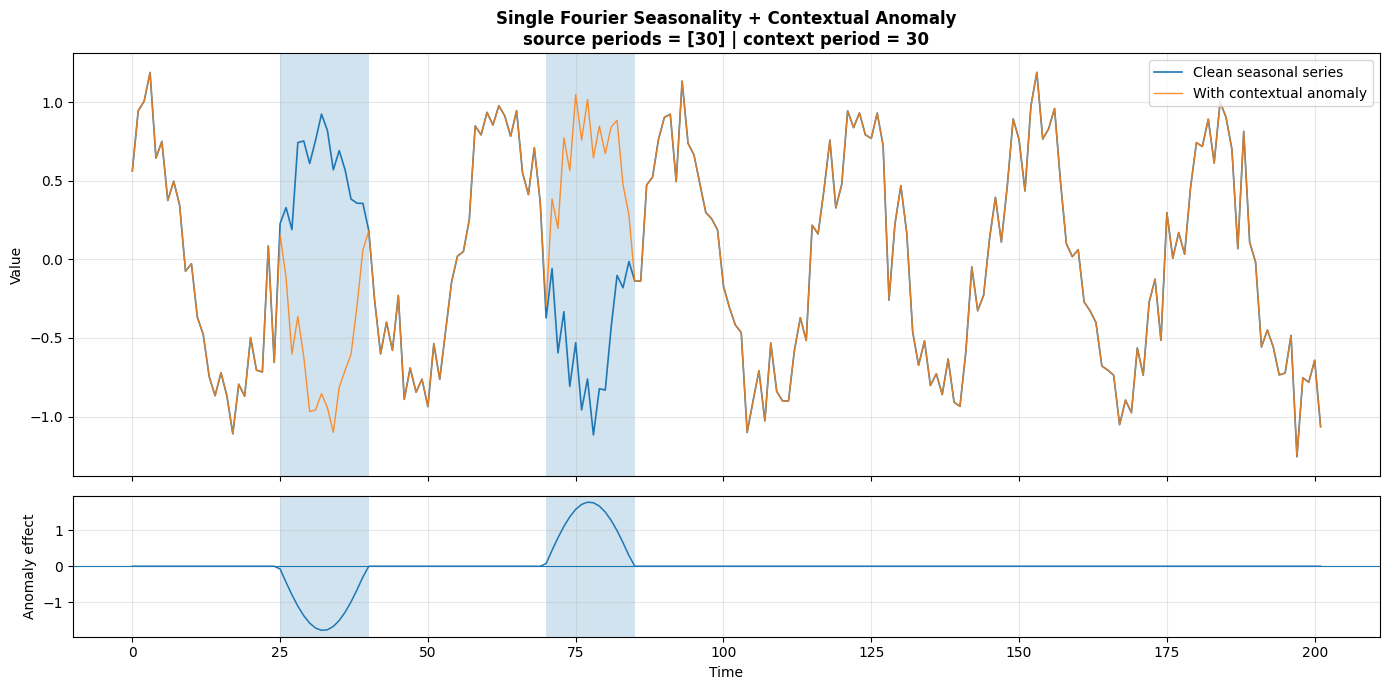

In [19]:
df_single_contextual, info_single_contextual = (
    ts_gen.generate_contextual_anomalies(
        df=df_single.copy(deep=True),
        seasonal_info=info_single,
        num_anomalies=2,
        anomaly_strength=1,
        is_loc=True
    )
)

check_contextual_case(
    df_single,
    df_single_contextual,
    info_single,
    info_single_contextual
)

plot_contextual_case(
    df_single,
    df_single_contextual,
    info_single,
    info_single_contextual,
    "Single Fourier Seasonality + Contextual Anomaly"
)


### 8.2 · Multiple Fourier Seasonalities + Contextual Anomaly

The source series contains more than one seasonal component. The contextual-anomaly
generator randomly selects **one of the existing periods** and violates the Fourier
context associated with that selected component.


PASS
  Source periods: [6, 5]
  Chosen context period: 6
  Period meaning: {6: [{'sampling_frequency': 'monthly', 'meaning': 'semiannual cycle'}]}
  Intervals: [(np.int64(50), np.int64(60)), (np.int64(86), np.int64(96))]


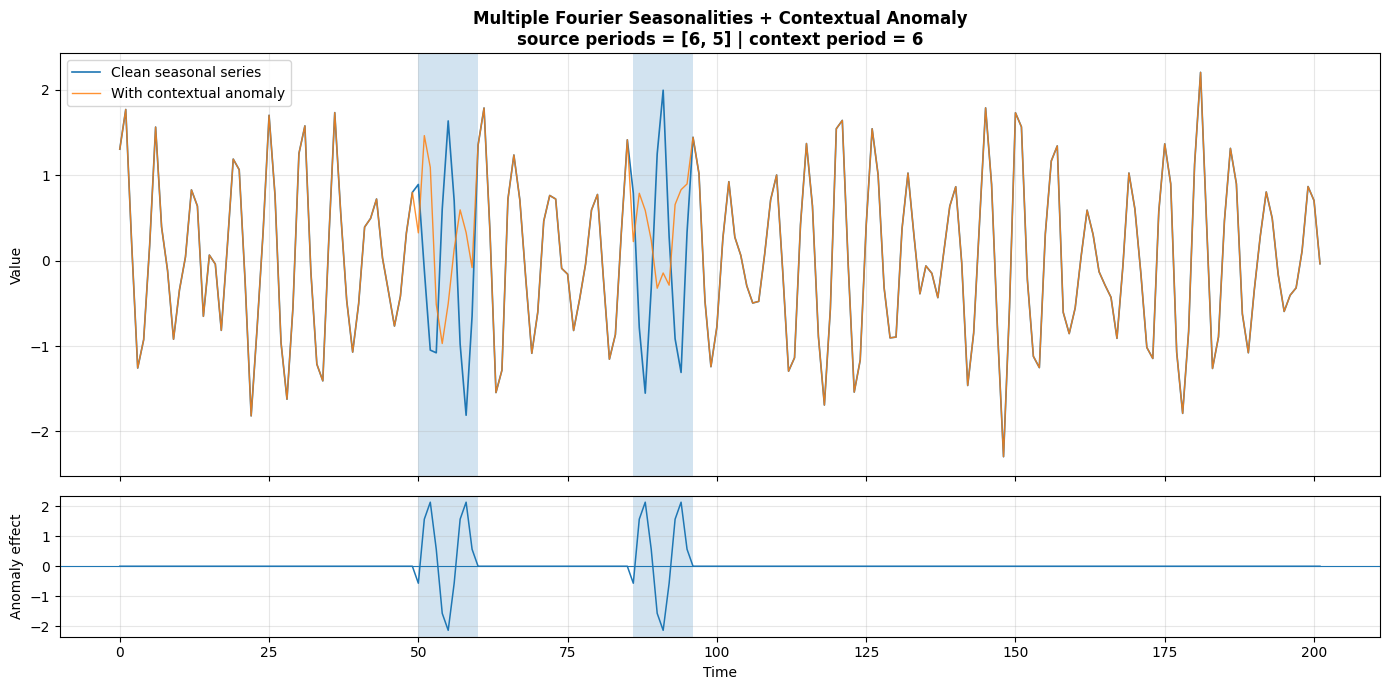

In [20]:
df_multiple_contextual, info_multiple_contextual = (
    ts_gen.generate_contextual_anomalies(
        df=df_multiple.copy(deep=True),
        seasonal_info=info_multiple,
        num_anomalies=2,
        anomaly_strength=1,
        is_loc=True
    )
)

check_contextual_case(
    df_multiple,
    df_multiple_contextual,
    info_multiple,
    info_multiple_contextual
)

plot_contextual_case(
    df_multiple,
    df_multiple_contextual,
    info_multiple,
    info_multiple_contextual,
    "Multiple Fourier Seasonalities + Contextual Anomaly"
)


### 8.3 · SARMA + Contextual Anomaly

For SARMA, the deterministic Fourier component is already in the same level domain
as the observed series. The stored Fourier component is therefore reconstructed
directly and used as the seasonal context.


PASS
  Source periods: [30]
  Chosen context period: 30
  Period meaning: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Intervals: [(np.int64(87), np.int64(102)), (np.int64(102), np.int64(117))]


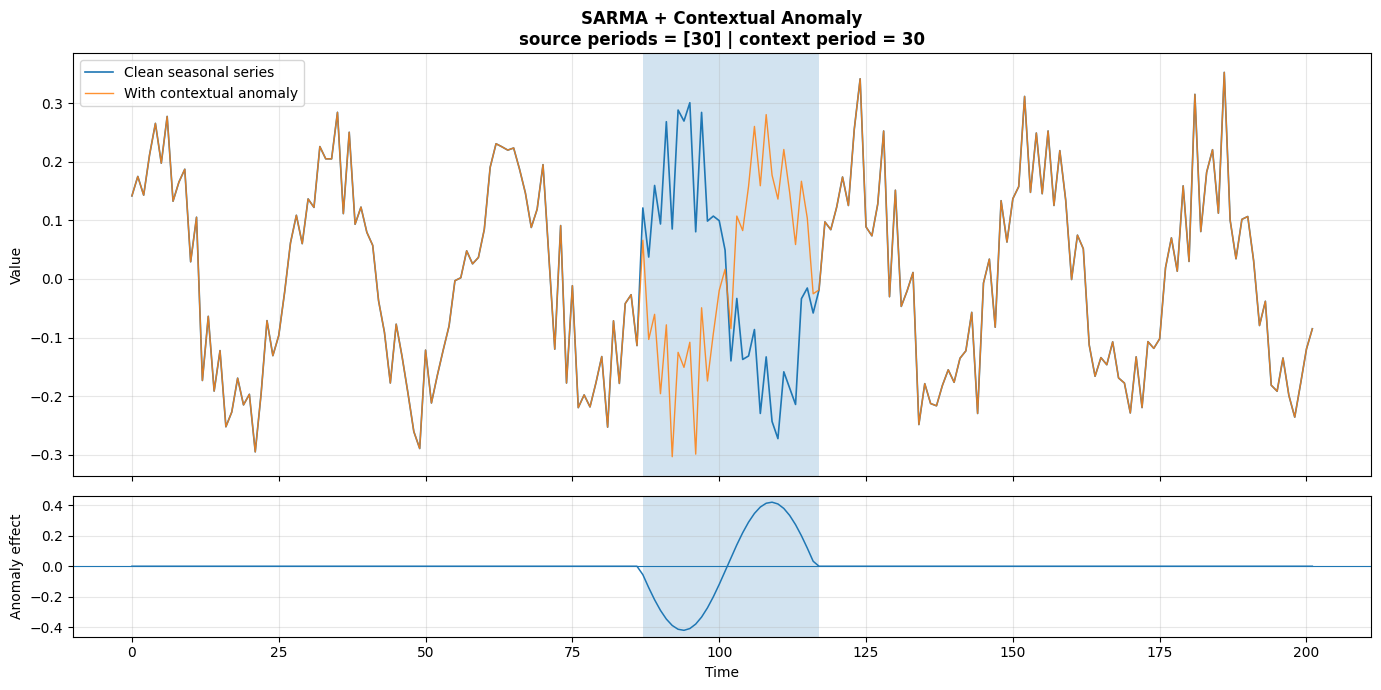

In [21]:
df_sarma_contextual, info_sarma_contextual = (
    ts_gen.generate_contextual_anomalies(
        df=df_sarma.copy(deep=True),
        seasonal_info=info_sarma,
        num_anomalies=2,
        anomaly_strength=1,
        is_loc=True
    )
)

check_contextual_case(
    df_sarma,
    df_sarma_contextual,
    info_sarma,
    info_sarma_contextual
)

plot_contextual_case(
    df_sarma,
    df_sarma_contextual,
    info_sarma,
    info_sarma_contextual,
    "SARMA + Contextual Anomaly"
)


### 8.4 · SARIMA + Contextual Anomaly

SARIMA requires one extra step.

Its stored Fourier component appears in the seasonally differenced relation

\[
Y_t - Y_{t-s} = F_t + \varepsilon_t.
\]

Therefore, the contextual-anomaly helper first seasonally integrates the reconstructed
Fourier term so that the reference has the same scale and domain as the observed
SARIMA series. The resulting level-domain seasonal context is then locally violated.


PASS
  Source periods: [30]
  Chosen context period: 30
  Period meaning: {30: [{'sampling_frequency': 'daily', 'meaning': 'monthly-ish cycle'}]}
  Intervals: [(np.int64(43), np.int64(58)), (np.int64(58), np.int64(73))]


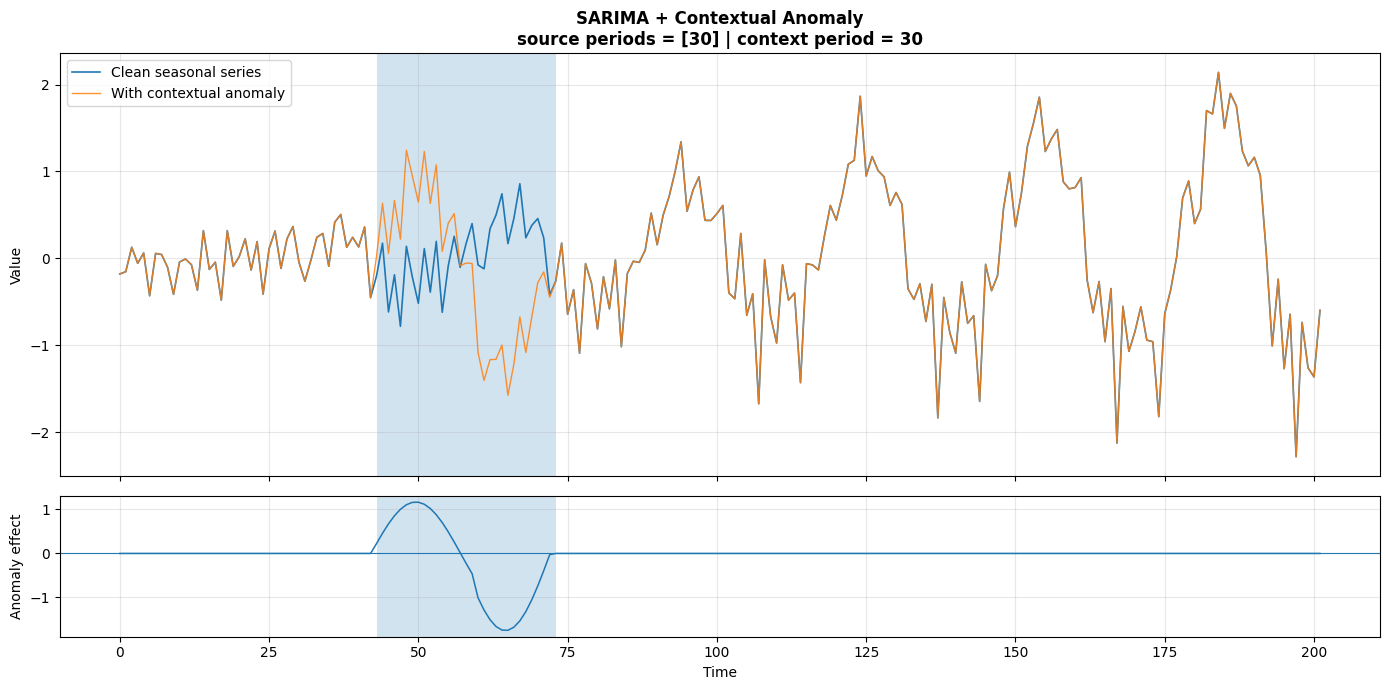

In [22]:
df_sarima_contextual, info_sarima_contextual = (
    ts_gen.generate_contextual_anomalies(
        df=df_sarima.copy(deep=True),
        seasonal_info=info_sarima,
        num_anomalies=2,
        anomaly_strength=1,
        is_loc=True
    )
)

check_contextual_case(
    df_sarima,
    df_sarima_contextual,
    info_sarima,
    info_sarima_contextual
)

plot_contextual_case(
    df_sarima,
    df_sarima_contextual,
    info_sarima,
    info_sarima_contextual,
    "SARIMA + Contextual Anomaly"
)


### 8.5 · Compare Contextual Anomalies Across All Four Seasonal Structures

The shaded regions indicate the generated contextual-anomaly intervals. In every
case, the contextual period must be one of the periods already present in the
corresponding seasonal series.


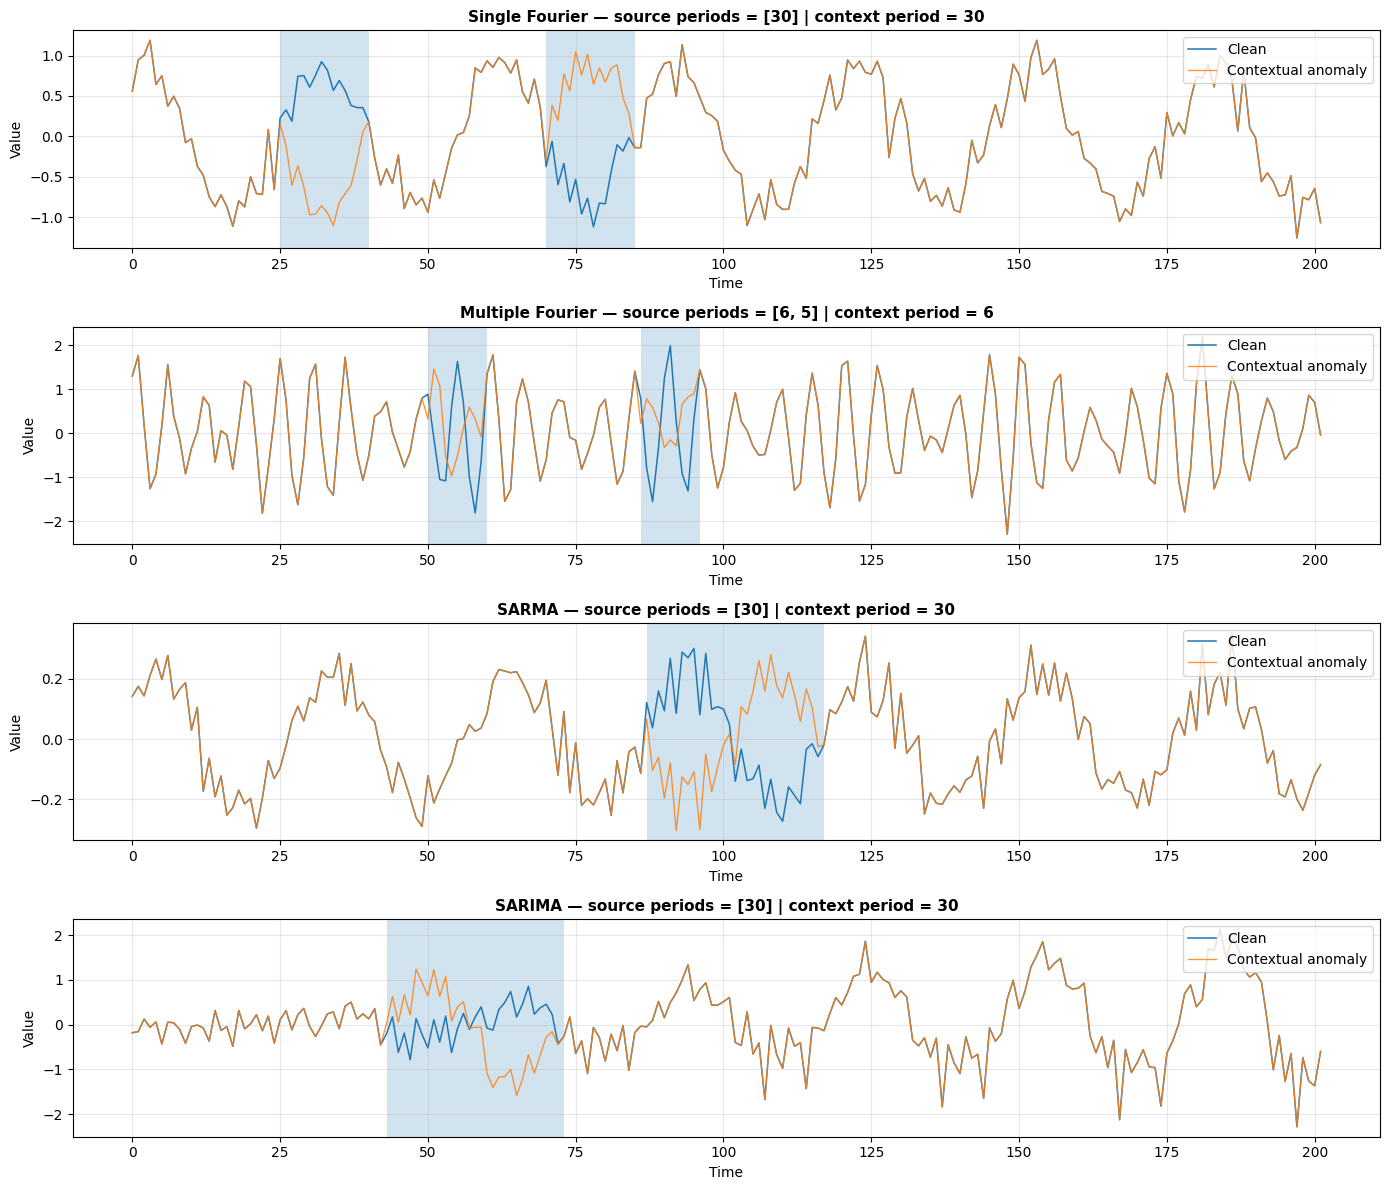

In [23]:
contextual_examples = {
    "Single Fourier": (
        df_single,
        df_single_contextual,
        info_single,
        info_single_contextual
    ),
    "Multiple Fourier": (
        df_multiple,
        df_multiple_contextual,
        info_multiple,
        info_multiple_contextual
    ),
    "SARMA": (
        df_sarma,
        df_sarma_contextual,
        info_sarma,
        info_sarma_contextual
    ),
    "SARIMA": (
        df_sarima,
        df_sarima_contextual,
        info_sarima,
        info_sarima_contextual
    ),
}

fig, axes = plt.subplots(
    4,
    1,
    figsize=(14, 12)
)

for ax, (
    label,
    (
        clean_df,
        anomaly_df,
        seasonal_info,
        anomaly_info
    )
) in zip(
    axes,
    contextual_examples.items()
):
    ax.plot(
        clean_df["time"],
        clean_df["data"],
        label="Clean",
        linewidth=1.1
    )

    ax.plot(
        anomaly_df["time"],
        anomaly_df["data"],
        label="Contextual anomaly",
        linewidth=0.95,
        alpha=0.85
    )

    for start, end in zip(
        anomaly_info["starts"],
        anomaly_info["ends"]
    ):
        ax.axvspan(
            start,
            end,
            alpha=0.20
        )

    ax.set_title(
        f"{label} — source periods = "
        f"{seasonal_info['periods']} | "
        f"context period = "
        f"{anomaly_info['periods'][0]}",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper right")

plt.tight_layout()
plt.show()


In [24]:
contextual_summary = pd.DataFrame([
    {
        "scenario": "single",
        "source_periods": info_single["periods"],
        "context_period": info_single_contextual["periods"][0],
        "num_anomalies": info_single_contextual["num_anomalies"],
        "starts": list(info_single_contextual["starts"]),
        "ends": list(info_single_contextual["ends"]),
    },
    {
        "scenario": "multiple",
        "source_periods": info_multiple["periods"],
        "context_period": info_multiple_contextual["periods"][0],
        "num_anomalies": info_multiple_contextual["num_anomalies"],
        "starts": list(info_multiple_contextual["starts"]),
        "ends": list(info_multiple_contextual["ends"]),
    },
    {
        "scenario": "SARMA",
        "source_periods": info_sarma["periods"],
        "context_period": info_sarma_contextual["periods"][0],
        "num_anomalies": info_sarma_contextual["num_anomalies"],
        "starts": list(info_sarma_contextual["starts"]),
        "ends": list(info_sarma_contextual["ends"]),
    },
    {
        "scenario": "SARIMA",
        "source_periods": info_sarima["periods"],
        "context_period": info_sarima_contextual["periods"][0],
        "num_anomalies": info_sarima_contextual["num_anomalies"],
        "starts": list(info_sarima_contextual["starts"]),
        "ends": list(info_sarima_contextual["ends"]),
    },
])

contextual_summary


,scenario,source_periods,context_period,num_anomalies,starts,ends
0,single,[30],30,2,"[25, 70]","[40, 85]"
1,multiple,"[6, 5]",6,2,"[50, 86]","[60, 96]"
2,SARMA,[30],30,2,"[87, 102]","[102, 117]"
3,SARIMA,[30],30,2,"[43, 58]","[58, 73]"
